In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform, os
import warnings
warnings.filterwarnings("ignore")

def set_korean_font():
    system = platform.system()
    if system == "Darwin":
        plt.rcParams["font.family"] = "AppleGothic"
    elif system == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:
        plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 80)
os.makedirs("../figures", exist_ok=True)

In [3]:
df = pd.read_csv("../../../data/processed/3_eda/step9_weather.csv",
                 encoding="utf-8-sig", low_memory=False)
for c in ["ABATT_DATE","BIRTH_YMD","JUDGE_DATE"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
if "grade_num" not in df.columns:
    grade_map = {"1++A":15,"1++B":14,"1++C":13,"1+A":12,"1+B":11,"1+C":10,
                 "1A":9,"1B":8,"1C":7,"2A":6,"2B":5,"2C":4,"3A":3,"3B":2,"3C":1,"등외":0}
    df["grade_num"] = df["LAST_GRADE"].map(grade_map)
print(f"데이터: {df.shape}")

데이터: (2408699, 50)


In [4]:
df["abatt_year"]    = df["ABATT_DATE"].dt.year
df["abatt_month"]   = df["ABATT_DATE"].dt.month
df["abatt_quarter"] = df["ABATT_DATE"].dt.quarter
df["birth_year"]    = df["BIRTH_YMD"].dt.year
df["birth_month"]   = df["BIRTH_YMD"].dt.month

def to_season(m):
    if m in [3,4,5]: return "봄"
    if m in [6,7,8]: return "여름"
    if m in [9,10,11]: return "가을"
    return "겨울"

if "abatt_season" not in df.columns:
    df["abatt_season"] = df["abatt_month"].apply(to_season)
if "birth_season" not in df.columns:
    df["birth_season"] = df["birth_month"].apply(to_season)
print("시간 변수 추가 완료")
print(df[["ABATT_DATE","abatt_year","abatt_month","abatt_season"]].head())

시간 변수 추가 완료
  ABATT_DATE  abatt_year  abatt_month abatt_season
0 2023-01-01        2023            1           겨울
1 2023-01-01        2023            1           겨울
2 2023-01-01        2023            1           겨울
3 2023-01-01        2023            1           겨울
4 2023-01-01        2023            1           겨울


                 n  mean_grade  mean_cost
abatt_year                               
2023        781368        9.35   15999.88
2024        835792        9.57   15964.38
2025        791539        9.81   18040.53


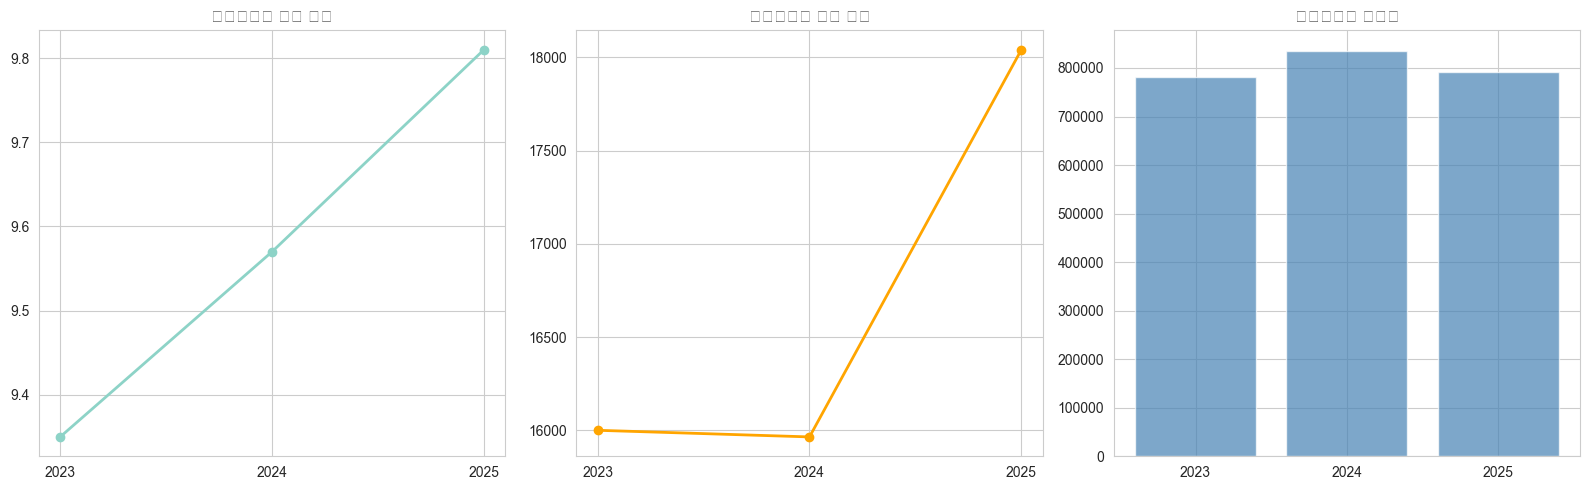

In [5]:
yearly = df.groupby("abatt_year").agg(
    n=("CATTLE_NO","count"),
    mean_grade=("grade_num","mean"),
    mean_cost=("COST_AMT","mean"),   # 결측 자동 제외
).round(2)
print(yearly)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(yearly.index, yearly["mean_grade"], marker="o", linewidth=2)
axes[0].set_title("도축연도별 평균 등급"); axes[0].set_xticks(yearly.index)
axes[1].plot(yearly.index, yearly["mean_cost"], marker="o", linewidth=2, color="orange")
axes[1].set_title("도축연도별 평균 가격"); axes[1].set_xticks(yearly.index)
axes[2].bar(yearly.index, yearly["n"], color="steelblue", alpha=0.7)
axes[2].set_title("도축연도별 마리수"); axes[2].set_xticks(yearly.index)
plt.tight_layout()
plt.savefig("../figures/16_yearly.png", dpi=100, bbox_inches="tight")
plt.show()

In [6]:
print("출생연도 분포:")
print(df["birth_year"].value_counts().sort_index())

old_cattle = df[df["birth_year"] <= 2015]
print(f"\\n2015년 이전 출생: {len(old_cattle):,}마리 "
      f"({len(old_cattle)/len(df)*100:.1f}%)")
if len(old_cattle) > 0:
    print(f"  평균 등급={old_cattle['grade_num'].mean():.2f} "
          f"(전체={df['grade_num'].mean():.2f})")

출생연도 분포:
birth_year
1996         2
1999         2
2000         4
2001         7
2002        11
2003        29
2004        76
2005       184
2006       303
2007       552
2008       956
2009      1646
2010      3103
2011      4724
2012      8341
2013     11177
2014     17603
2015     27252
2016     43522
2017     68214
2018    114532
2019    171004
2020    423460
2021    661924
2022    602288
2023    245411
2024      2326
2025        46
Name: count, dtype: int64
\n2015년 이전 출생: 75,972마리 (3.2%)
  평균 등급=3.73 (전체=9.58)


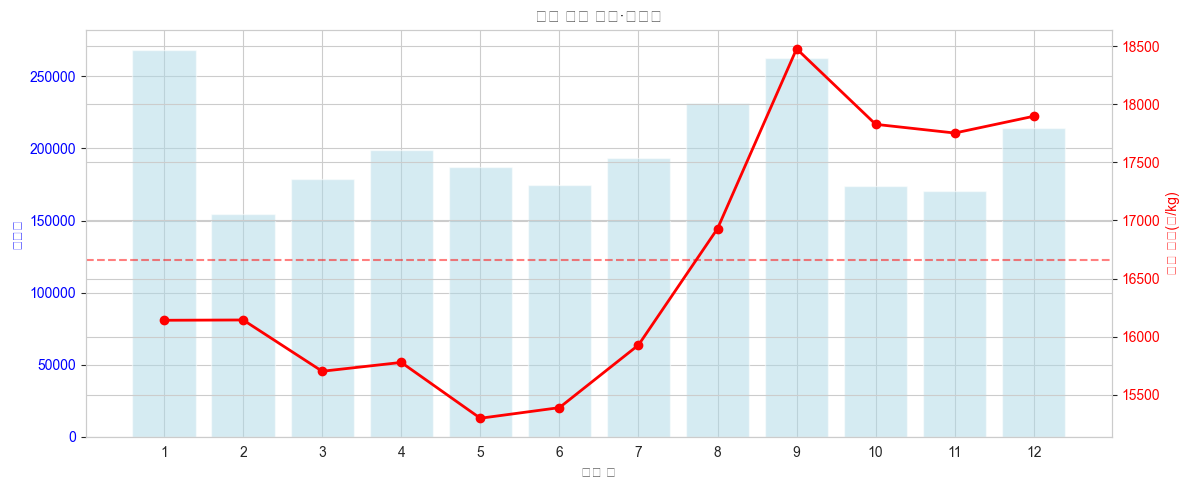

In [7]:
monthly = df.groupby("abatt_month").agg(
    n=("CATTLE_NO","count"), mean_cost=("COST_AMT","mean"))

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(monthly.index, monthly["n"], color="lightblue", alpha=0.5, label="마리수")
ax1.set_xlabel("도축 월"); ax1.set_ylabel("마리수", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["mean_cost"], marker="o", color="red",
         linewidth=2, label="평균 가격")
ax2.set_ylabel("평균 가격(원/kg)", color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax2.axhline(y=df["COST_AMT"].mean(), color="red", linestyle="--", alpha=0.5)
plt.title("도축 월별 가격·출하량")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig("../figures/16_monthly.png", dpi=100, bbox_inches="tight")
plt.show()

In [8]:
sido_summary = df.groupby("sido").agg(
    n=("CATTLE_NO","count"),
    mean_grade=("grade_num","mean"),
    mean_cost=("COST_AMT","mean"),
).round(2).sort_values("mean_grade", ascending=False)
if "ratio_고온" in df.columns:
    sido_summary["mean_고온"] = df.groupby("sido")["ratio_고온"].mean().round(3)
print(sido_summary)

              n  mean_grade  mean_cost  mean_고온
sido                                           
인천광역시     15284       11.13   18653.35    0.377
제주특별자치도   19448        9.91   14586.12    0.397
경상북도     605621        9.82   16730.64    0.414
전북특별자치도  295666        9.72   17107.03    0.424
충청북도     138979        9.65   16799.24    0.413
전라남도     409421        9.59   17335.90    0.423
세종특별자치시   18094        9.58   16955.51    0.427
울산광역시     20519        9.56   16065.29    0.383
경기도      214181        9.56   16329.34    0.410
강원특별자치도  153026        9.42   15597.15    0.375
경상남도     203066        9.20   16111.09    0.430
대구광역시     18811        9.18   15802.85    0.434
광주광역시      3208        9.18   17540.32    0.453
충청남도     289493        9.16   16416.36    0.412
대전광역시      3657        9.09   16208.54    0.413
부산광역시       181        7.80   14620.26    0.417
서울특별시        44        7.52   14156.05    0.401


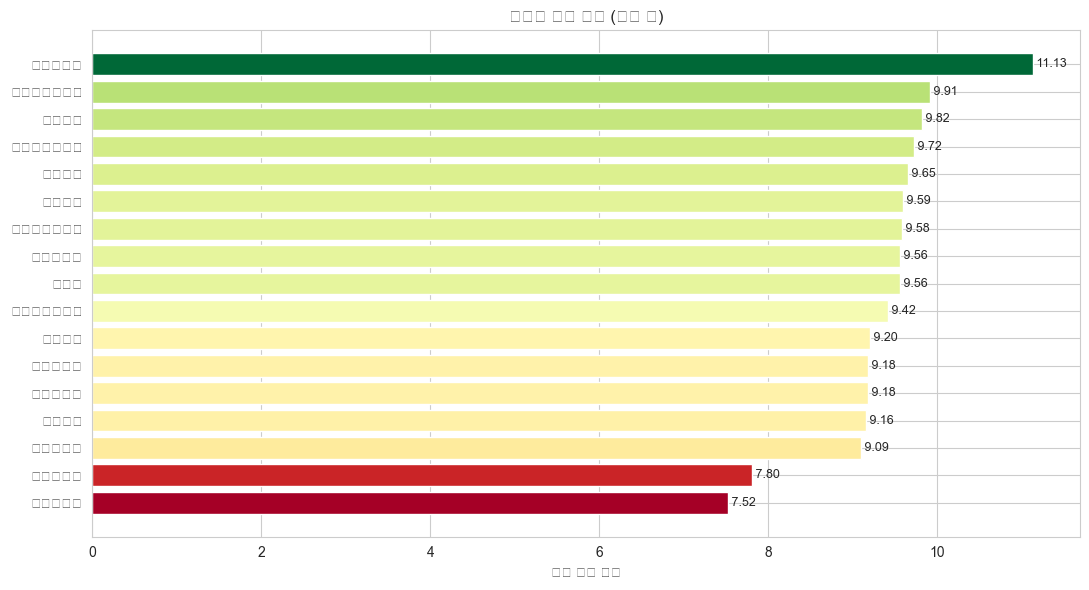

In [9]:
sido_sorted = sido_summary.sort_values("mean_grade")
plt.figure(figsize=(11, 6))
colors = plt.cm.RdYlGn(
    (sido_sorted["mean_grade"] - sido_sorted["mean_grade"].min())
    / (sido_sorted["mean_grade"].max() - sido_sorted["mean_grade"].min()))
plt.barh(range(len(sido_sorted)), sido_sorted["mean_grade"], color=colors)
plt.yticks(range(len(sido_sorted)), sido_sorted.index)
plt.xlabel("평균 등급 점수")
plt.title("시도별 평균 등급 (낮은 순)")
for i, (idx, row) in enumerate(sido_sorted.iterrows()):
    plt.text(row["mean_grade"], i, f" {row['mean_grade']:.2f}",
             va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/16_sido_grade.png", dpi=100, bbox_inches="tight")
plt.show()

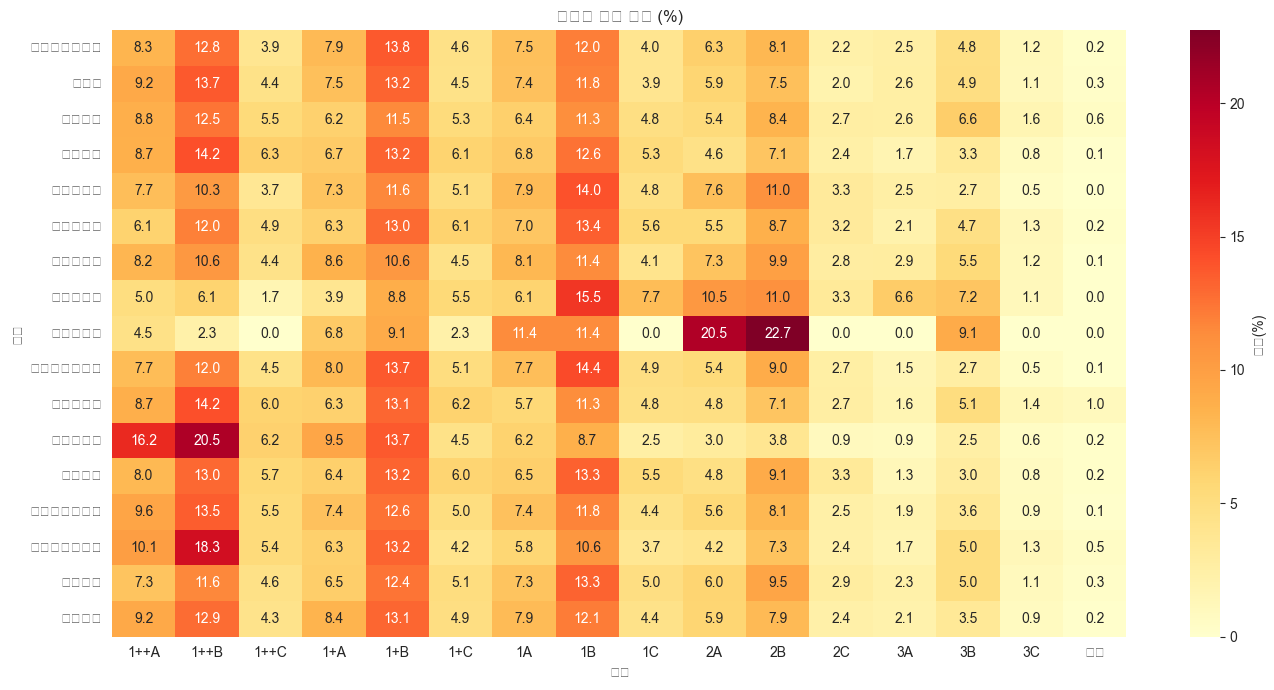

In [10]:
grade_order = ["1++A","1++B","1++C","1+A","1+B","1+C",
               "1A","1B","1C","2A","2B","2C","3A","3B","3C","등외"]
grade_order = [g for g in grade_order if g in df["LAST_GRADE"].unique()]
grade_pivot = pd.crosstab(df["sido"], df["LAST_GRADE"], normalize="index") * 100
grade_pivot = grade_pivot[grade_order]
plt.figure(figsize=(14, 7))
sns.heatmap(grade_pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={"label": "비율(%)"})
plt.title("시도별 등급 분포 (%)")
plt.xlabel("등급"); plt.ylabel("시도")
plt.tight_layout()
plt.savefig("../figures/16_sido_grade_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()

In [11]:
# 임계값: 20 이하 원-핫 가능, 200 이하 Target, 그 이상 제외 검토
for col in ["sido", "sigungu", "eupmyeondong"]:
    n = df[col].nunique()
    counts = df[col].value_counts()
    small = (counts < 30).sum()
    print(f"\\n=== {col} ===")
    print(f"종류 수: {n}개")
    print(f"마리수 30 미만 희소 카테고리: {small}개")
    if n <= 20:
        decision = "원-핫 인코딩(회귀) / 범주형 그대로(LightGBM)"
    elif n <= 200:
        decision = "Target Encoding (18회차 분할 후 OOF)"
    else:
        decision = "Target Encoding 또는 제외"
    print(f"결정: {decision}")

\n=== sido ===
종류 수: 17개
마리수 30 미만 희소 카테고리: 0개
결정: 원-핫 인코딩(회귀) / 범주형 그대로(LightGBM)
\n=== sigungu ===
종류 수: 184개
마리수 30 미만 희소 카테고리: 8개
결정: Target Encoding (18회차 분할 후 OOF)
\n=== eupmyeondong ===
종류 수: 1306개
마리수 30 미만 희소 카테고리: 146개
결정: Target Encoding 또는 제외


In [12]:
df.to_csv("../../../data/processed/3_eda/step10_spatial.csv",
          index=False, encoding="utf-8-sig")
print(f"저장 완료: step10_spatial.csv {df.shape}")
print("추가 컬럼: abatt_year/month/quarter, birth_year/month")

저장 완료: step10_spatial.csv (2408699, 56)
추가 컬럼: abatt_year/month/quarter, birth_year/month
